## Spengler Cup Finale 2025: Davos vs. US Collegiate Selects 
Home = HCD; Away = US Collegiate Selects

In [140]:
from hockey_rink import NHLRink
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from pathlib import Path

In [141]:
data_dir = Path("/Users/enrue/Developer/playground/hockey-dataset/data")
csv_files = list(data_dir.glob("*.csv"))
df = pd.read_csv(csv_files[0])

In [142]:
# Chronologisch sortieren
df = df.sort_values(["Period", "MatchClock", "Timestamp"]).reset_index(drop=True)

In [143]:
# Nimmt vorherigen Wert aus TeamStrenghtType in leere Spalten (StoppageOfPlay)
df["strength_type_state"] = df["TeamStrengthType"].ffill()

In [144]:
# Hilfsspalte PP = True ; alles andere = False
df["is_powerplay"] = df["strength_type_state"].isin(["HomePowerplay", "AwayPowerplay"])

In [145]:
# Beginn eines neuen Powerplays erkennen (".shift()" vergleicht jede Zeile mit der  vorherigen)
# pp_start ist nur dann True, wenn ein Powerplay läuft und sich der Zustand gegenüber der vorherigen Zeile geändert hat.
df["pp_start"] = (df["is_powerplay"] & df["strength_type_state"].ne(df["strength_type_state"].shift()))

In [146]:
# IDs für zusammenhängende Überzahl auf dem Eis
df["pp_phase_id"] = (df["pp_start"].cumsum().where(df["is_powerplay"]))

Wie mit doppelstrafen umgehen? 
Finley erhält 2x2 min Strafe (MatchClock 1186)

In [147]:
df.head()

,Period,MatchClock,Timestamp,EventType,TeamStrengthType,TeamStrength,HomeGoalieOnIce,AwayGoalieOnIce,EventPosition,EventStartCoordinate,...,StartPlayerDirection7,StartPlayerDirection8,StartPlayerDirection9,StartPlayerDirection10,StartPlayerDirection11,StartPlayerDirection12,strength_type_state,is_powerplay,pp_start,pp_phase_id
0,1,0,1767179427880,Faceoff,FullStrength,5v5,True,True,NeutralZone,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,FullStrength,False,False,NaN
1,1,0,1767179428340,PuckControl,FullStrength,5v5,True,True,NeutralZone,"-1.4,0.1",...,NaN,NaN,NaN,NaN,NaN,NaN,FullStrength,False,False,NaN
2,1,0,1767179428380,PuckControl,FullStrength,5v5,True,True,NeutralZone,"-1.5,0.2",...,NaN,NaN,NaN,NaN,NaN,NaN,FullStrength,False,False,NaN
3,1,0,1767179428600,Pass,FullStrength,5v5,True,True,NeutralZone,"-1.8,-0.1",...,"-0.998,0.063","1,-0.017","-0.684,0.729","-0.661,-0.75","-0.995,0.1","-0.873,-0.488",FullStrength,False,False,NaN
4,1,0,1767179428620,PuckControl,FullStrength,5v5,True,True,NeutralZone,"-1.9,-0.1",...,NaN,NaN,NaN,NaN,NaN,NaN,FullStrength,False,False,NaN


In [148]:
df_pp_1 = df[df["pp_phase_id"] == 1].copy()
df_pp_2 = df[df["pp_phase_id"] == 2].copy()
df_pp_3 = df[df["pp_phase_id"] == 3].copy()
df_pp_4 = df[df["pp_phase_id"] == 4].copy()

In [149]:
# Dauerte nur 3 Sekunden aufgrund eines Goals? 
# Player: Aiden Fink
# Foul: Slashing
df_pp_1

,Period,MatchClock,Timestamp,EventType,TeamStrengthType,TeamStrength,HomeGoalieOnIce,AwayGoalieOnIce,EventPosition,EventStartCoordinate,...,StartPlayerDirection7,StartPlayerDirection8,StartPlayerDirection9,StartPlayerDirection10,StartPlayerDirection11,StartPlayerDirection12,strength_type_state,is_powerplay,pp_start,pp_phase_id
843,1,672,1767180588740,Faceoff,AwayPowerplay,4v5,True,True,HomeTeamZone,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,AwayPowerplay,True,True,1.0
844,1,672,1767180588740,PuckControl,AwayPowerplay,4v5,True,True,HomeTeamZone,"-19,8.8",...,NaN,NaN,NaN,NaN,NaN,NaN,AwayPowerplay,True,False,1.0
845,1,672,1767180589000,PuckControl,AwayPowerplay,4v5,True,True,HomeTeamZone,"-17.1,10.3",...,NaN,NaN,NaN,NaN,NaN,NaN,AwayPowerplay,True,False,1.0
846,1,674,1767180590680,Shot,AwayPowerplay,4v5,True,True,HomeTeamZone,"-14.3,3.4",...,"-0.144,-0.99","0.941,-0.34","0.125,-0.992","0.889,-0.457","-0.276,-0.961",NaN,AwayPowerplay,True,False,1.0
847,1,674,1767180590700,PuckControl,AwayPowerplay,4v5,True,True,HomeTeamZone,"-14.3,3.3",...,NaN,NaN,NaN,NaN,NaN,NaN,AwayPowerplay,True,False,1.0
848,1,674,1767180591280,PuckControl,AwayPowerplay,4v5,True,True,HomeTeamZone,"-26.1,-0.2",...,NaN,NaN,NaN,NaN,NaN,NaN,AwayPowerplay,True,False,1.0
849,1,675,1767180592300,Goal,AwayPowerplay,4v5,True,True,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,AwayPowerplay,True,False,1.0
850,1,675,1767180592300,StoppageOfPlay,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,AwayPowerplay,True,False,1.0


In [150]:
# Player: Calle Andersson 
# Foul: Cross-Check
df_pp_2

,Period,MatchClock,Timestamp,EventType,TeamStrengthType,TeamStrength,HomeGoalieOnIce,AwayGoalieOnIce,EventPosition,EventStartCoordinate,...,StartPlayerDirection7,StartPlayerDirection8,StartPlayerDirection9,StartPlayerDirection10,StartPlayerDirection11,StartPlayerDirection12,strength_type_state,is_powerplay,pp_start,pp_phase_id
1205,1,927,1767181154680,Faceoff,HomePowerplay,5v4,True,True,AwayTeamZone,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,HomePowerplay,True,True,2.0
1206,1,928,1767181155100,PuckControl,HomePowerplay,5v4,True,True,AwayTeamZone,"21.8,-8.8",...,NaN,NaN,NaN,NaN,NaN,NaN,HomePowerplay,True,False,2.0
1207,1,929,1767181156040,PuckControl,HomePowerplay,5v4,True,True,AwayTeamZone,"27.4,-7",...,NaN,NaN,NaN,NaN,NaN,NaN,HomePowerplay,True,False,2.0
1208,1,930,1767181157280,PuckControl,HomePowerplay,5v4,True,True,AwayTeamZone,"28.2,-12.5",...,NaN,NaN,NaN,NaN,NaN,NaN,HomePowerplay,True,False,2.0
1209,1,930,1767181157700,PuckControl,HomePowerplay,5v4,True,True,AwayTeamZone,"26,-13.6",...,NaN,NaN,NaN,NaN,NaN,NaN,HomePowerplay,True,False,2.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1335,1,1045,1767181302300,Pass,HomePowerplay,5v4,True,True,AwayTeamZone,"7.9,11.9",...,"-0.999,0.054","-0.972,-0.236","-0.937,-0.348","-0.976,0.217","-0.951,-0.309",NaN,HomePowerplay,True,False,2.0
1336,1,1045,1767181302320,PuckControl,HomePowerplay,5v4,True,True,AwayTeamZone,"7.8,11.8",...,NaN,NaN,NaN,NaN,NaN,NaN,HomePowerplay,True,False,2.0
1337,1,1045,1767181302400,BluelineCrossing,HomePowerplay,5v4,True,True,AwayTeamZone,"7.2,11.1",...,"-0.995,0.096","-0.961,-0.276","-0.929,-0.371","-0.974,0.226","-0.93,-0.366",NaN,HomePowerplay,True,False,2.0
1338,1,1046,1767181303140,PuckControl,HomePowerplay,5v4,True,True,NeutralZone,"-0.2,-0.5",...,NaN,NaN,NaN,NaN,NaN,NaN,HomePowerplay,True,False,2.0


In [151]:
# PP über drittelsende hinweg
df_pp_3

,Period,MatchClock,Timestamp,EventType,TeamStrengthType,TeamStrength,HomeGoalieOnIce,AwayGoalieOnIce,EventPosition,EventStartCoordinate,...,StartPlayerDirection7,StartPlayerDirection8,StartPlayerDirection9,StartPlayerDirection10,StartPlayerDirection11,StartPlayerDirection12,strength_type_state,is_powerplay,pp_start,pp_phase_id
2957,2,1187,1767184603780,Faceoff,AwayPowerplay,4v5,True,True,HomeTeamZone,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,AwayPowerplay,True,True,3.0
2958,2,1187,1767184603780,PuckControl,AwayPowerplay,4v5,True,True,HomeTeamZone,"-20.8,6.8",...,NaN,NaN,NaN,NaN,NaN,NaN,AwayPowerplay,True,False,3.0
2959,2,1187,1767184604100,PuckControl,AwayPowerplay,4v5,True,True,HomeTeamZone,"-21.3,6.1",...,NaN,NaN,NaN,NaN,NaN,NaN,AwayPowerplay,True,False,3.0
2960,2,1188,1767184604380,PuckControl,AwayPowerplay,4v5,True,True,HomeTeamZone,"-23.8,5.6",...,NaN,NaN,NaN,NaN,NaN,NaN,AwayPowerplay,True,False,3.0
2961,2,1188,1767184605060,Clear,AwayPowerplay,4v5,True,True,HomeTeamZone,"-24.9,8.7",...,"0.509,-0.861","-0.074,0.997","-0.558,-0.83","0.873,0.488","-0.253,-0.968",NaN,AwayPowerplay,True,False,3.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3232,3,221,1767185954920,StoppageOfPlay,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,AwayPowerplay,True,False,3.0
3233,3,221,1767186026400,Faceoff,AwayPowerplay,4v5,True,True,HomeTeamZone,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,AwayPowerplay,True,False,3.0
3234,3,221,1767186026400,PuckControl,AwayPowerplay,4v5,True,True,HomeTeamZone,"-20,7.3",...,NaN,NaN,NaN,NaN,NaN,NaN,AwayPowerplay,True,False,3.0
3235,3,225,1767186030200,BluelineCrossing,AwayPowerplay,4v5,True,True,NeutralZone,"-7.1,-14.6",...,"0.756,-0.654","0.539,-0.842","0.981,-0.194","0.955,-0.296","0.995,0.098",NaN,AwayPowerplay,True,False,3.0


In [152]:
df_pp_4

,Period,MatchClock,Timestamp,EventType,TeamStrengthType,TeamStrength,HomeGoalieOnIce,AwayGoalieOnIce,EventPosition,EventStartCoordinate,...,StartPlayerDirection7,StartPlayerDirection8,StartPlayerDirection9,StartPlayerDirection10,StartPlayerDirection11,StartPlayerDirection12,strength_type_state,is_powerplay,pp_start,pp_phase_id
4218,3,1008,1767187643040,Faceoff,AwayPowerplay,4v5,True,True,NeutralZone,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,AwayPowerplay,True,True,4.0
4219,3,1008,1767187643040,PuckControl,AwayPowerplay,4v5,True,True,NeutralZone,"-2.4,-1",...,NaN,NaN,NaN,NaN,NaN,NaN,AwayPowerplay,True,False,4.0
4220,3,1008,1767187643440,PuckControl,AwayPowerplay,4v5,True,True,NeutralZone,"-6.1,-3.4",...,NaN,NaN,NaN,NaN,NaN,NaN,AwayPowerplay,True,False,4.0
4221,3,1008,1767187643580,BluelineCrossing,AwayPowerplay,4v5,True,True,NeutralZone,"-7.1,-4.1",...,"-0.857,-0.516","0.647,0.762","-0.729,-0.684","-0.353,-0.936","0.901,0.433",NaN,AwayPowerplay,True,False,4.0
4222,3,1010,1767187644880,Clear,AwayPowerplay,4v5,True,True,HomeTeamZone,"-9.3,-10.4",...,"-0.974,-0.227","0.804,0.595","-0.068,-0.998","-0.169,-0.986","0.992,-0.126",NaN,AwayPowerplay,True,False,4.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4437,3,1187,1767187985280,Pass,AwayPowerplay,4v5,True,True,HomeTeamZone,"-17.8,12.1",...,"-0.337,0.942","-0.141,0.99","0.29,-0.957","-0.847,-0.532","-0.686,-0.727",NaN,AwayPowerplay,True,False,4.0
4438,3,1187,1767187985300,PuckControl,AwayPowerplay,4v5,True,True,HomeTeamZone,"-17.8,12",...,NaN,NaN,NaN,NaN,NaN,NaN,AwayPowerplay,True,False,4.0
4439,3,1187,1767187985880,Shot,AwayPowerplay,4v5,True,True,HomeTeamZone,"-21.1,-2.2",...,"-0.938,-0.346","0.991,0.133","-0.764,-0.645","-0.933,0.359","-0.894,-0.448",NaN,AwayPowerplay,True,False,4.0
4440,3,1187,1767187985880,PuckControl,AwayPowerplay,4v5,True,True,HomeTeamZone,"-21.1,-2.2",...,NaN,NaN,NaN,NaN,NaN,NaN,AwayPowerplay,True,False,4.0


In [154]:
df_pp_1.to_csv("pp_1.csv", index=False)
df_pp_2.to_csv("pp_2.csv", index=False)
df_pp_3.to_csv("pp_3.csv", index=False)
df_pp_4.to_csv("pp_4.csv", index=False)

In [166]:
from hockey_rink import *
import matplotlib.pyplot as plt
import urllib.error
import urllib.request

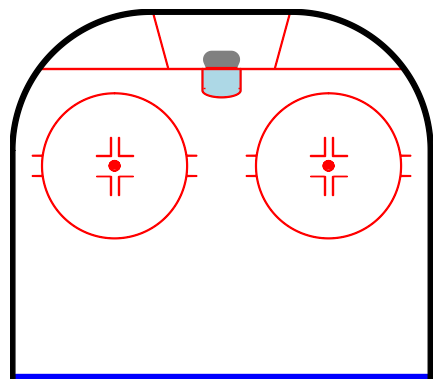

In [168]:
rink = NHLRink()
rink.draw(display_range="ozone", rotation=90)
plt.show()

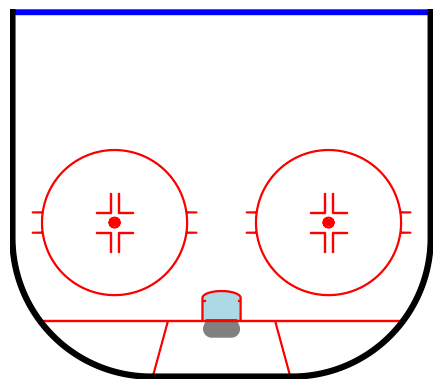

In [169]:
rink = NHLRink()
rink.draw(display_range="dzone", rotation=90)
plt.show()